In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ---- project imports ----
from sim.frame import make_blank_frame
from sim.render import RenderConfig, render, plot_render_stages
from sim.camera import Camera
from sim.lens import Lens
from sim.physics.noise import apply_noise

stars_pre_psf sum: 46773136.0
stars_post_psf sum: 46737570.0
flux ratio: 0.99923956

post_psf stats:
min: -9.264971e-11
median: -2.8861655e-15
max: 1051881.2


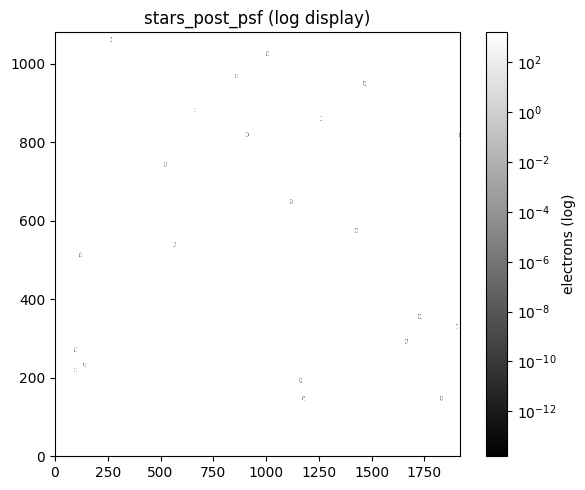

In [43]:
# ---- configuration ----
STAR_CSV = "sim/physics/starfields/field2.csv"

RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

cam = Camera(
    nx=1920,
    ny=1080,
    pixel_um=3.75,
    read_noise_e=0.0,
    gain_e_per_adu=1.0,
    qe=0.6,
)

lens = Lens(
    focal_mm=500.0,
    f_number=2.0,
    transmission=0.9
)

cfg = RenderConfig(
    exposure_s=100.0,
    sky_e_per_px_s=3.0,
    zeropoint_e_per_s=0,
    psf_sigma_px=1.2,
    enable_psf=True,
    enable_mask=False,
    enable_jitter=False,
    enable_noise=False,
)

# ---- render ----
frame = make_blank_frame(cam, lens,
                         ra0_deg=RA0_DEG,
                         dec0_deg=DEC0_DEG,
                         rot_deg=ROT_DEG)

frame, res = render(frame, cfg, stars=STAR_CSV)

# ===============================
# NUMERICAL CHECKS
# ===============================

print("stars_pre_psf sum:", np.sum(res.stars_e_pre_psf))
print("stars_post_psf sum:", np.sum(res.stars_e_post_psf))
print("flux ratio:", np.sum(res.stars_e_post_psf) / np.sum(res.stars_e_pre_psf))

print("\npost_psf stats:")
print("min:", np.min(res.stars_e_post_psf))
print("median:", np.median(res.stars_e_post_psf))
print("max:", np.max(res.stars_e_post_psf))

# ===============================
# VISUAL CHECK (LOG SCALE)
# ===============================

img = res.stars_e_post_psf
pos = img[img > 0]

vmin = np.percentile(pos, 1)
vmax = np.percentile(pos, 99.9)

plt.figure(figsize=(6,5))
plt.imshow(img,
           origin="lower",
           cmap="gray",
           norm=LogNorm(vmin=vmin, vmax=vmax),
           interpolation="nearest",
           aspect="auto")
plt.colorbar(label="electrons (log)")
plt.title("stars_post_psf (log display)")
plt.tight_layout()
plt.show()

Brightest star center: 1622 1006


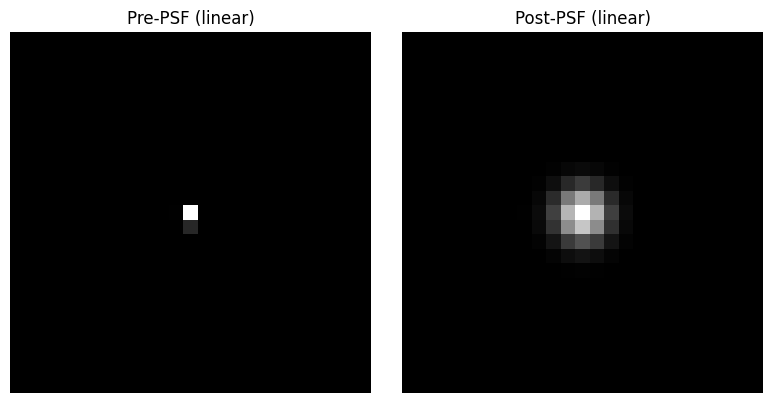

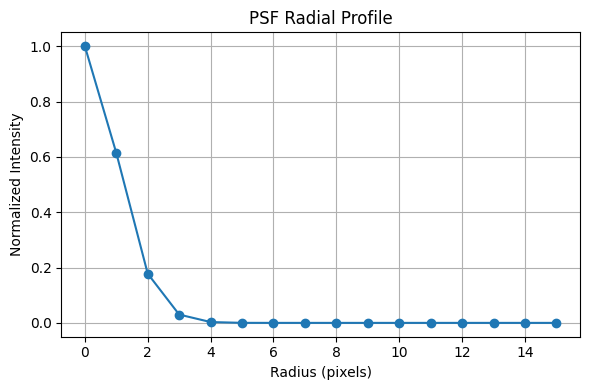

In [6]:
# ===============================
# PSF DIAGNOSTIC TEST
# ===============================

img_pre  = res.stars_e_pre_psf
img_post = res.stars_e_post_psf

ny, nx = img_pre.shape

# ---- find brightest star center (pre-PSF image) ----
y0, x0 = np.unravel_index(np.argmax(img_pre), img_pre.shape)

print("Brightest star center:", x0, y0)

# ---- extract cutouts ----
half = 12

y1 = max(0, y0-half)
y2 = min(ny, y0+half+1)
x1 = max(0, x0-half)
x2 = min(nx, x0+half+1)

cut_pre  = img_pre[y1:y2, x1:x2]
cut_post = img_post[y1:y2, x1:x2]

# ---- display cutouts (LINEAR scaling) ----
fig, axs = plt.subplots(1,2, figsize=(8,4))

axs[0].imshow(cut_pre,
              origin="lower",
              cmap="gray")
axs[0].set_title("Pre-PSF (linear)")
axs[0].axis("off")

axs[1].imshow(cut_post,
              origin="lower",
              cmap="gray")
axs[1].set_title("Post-PSF (linear)")
axs[1].axis("off")

plt.tight_layout()
plt.show()


# ===============================
# RADIAL PROFILE TEST
# ===============================

# build radius grid
h, w = cut_post.shape
cy = (h-1)/2
cx = (w-1)/2

y, x = np.indices((h, w))
r = np.sqrt((x-cx)**2 + (y-cy)**2)

# flatten
r_flat = r.ravel()
I_flat = cut_post.ravel()

# bin radii
r_max = int(np.max(r))
radial_mean = []

for rr in range(r_max):
    mask = (r_flat >= rr) & (r_flat < rr+1)
    if np.any(mask):
        radial_mean.append(np.mean(I_flat[mask]))
    else:
        radial_mean.append(np.nan)

radial_mean = np.array(radial_mean)

# normalize
radial_mean /= np.max(radial_mean)

plt.figure(figsize=(6,4))
plt.plot(radial_mean, 'o-')
plt.xlabel("Radius (pixels)")
plt.ylabel("Normalized Intensity")
plt.title("PSF Radial Profile")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
np.max(img_pre)

0.071796924

In [11]:
from sim.physics.stars import load_star_field

sf = load_star_field(STAR_CSV)
print("mag range:", np.min(sf.mag), np.median(sf.mag), np.max(sf.mag))

# predicted total electrons for each star (your simple model)
t = cfg.exposure_s
zp = cfg.zeropoint_e_per_s
e = t * zp * (10.0 ** (-0.4 * sf.mag))

print("pred e- per star: min/med/max:", e.min(), np.median(e), e.max())

mag range: 2.0645833 11.205677 11.999997
pred e- per star: min/med/max: 0.00316979514337778 0.0065880850277293046 29.86734892784953


Derived zeropoint (mag=0): 13696736.76750387 e-/s

Override ZP=2.0, exposure=100s
stars_pre max: 0.3090807795524597
stars_post max: 0.05899469926953316
mean max: 300.0589904785156

Derived ZP (override=0.0), exposure=0.01s
stars_pre max: 211.66990661621094
stars_post max: 40.40174102783203
mean max: 40.431739807128906


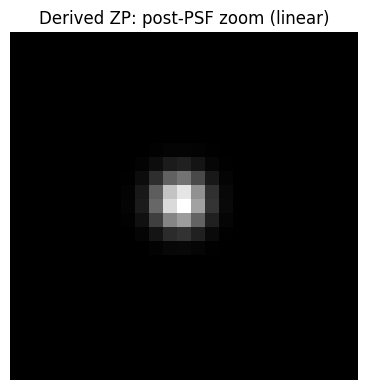

In [12]:
from sim.camera import Camera
from sim.lens import Lens
from sim.frame import make_blank_frame
from sim.render import render, RenderConfig
from sim.physics.stars import derive_zeropoint_e_per_s

STAR_CSV = "sim/physics/starfields/field2.csv"

RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

cam = Camera(
    nx=1920, ny=1080,
    pixel_um=3.75,
    read_noise_e=0.0,
    gain_e_per_adu=1.0,
    qe=0.6,
)

lens = Lens(
    focal_mm=120.0,
    f_number=2.0,
    transmission=0.9
)

# compute derived ZP directly (same function stars_layer uses)
zp_der = derive_zeropoint_e_per_s(lens, cam.qe, lambda_eff_nm=550.0, band_nm=90.0)
print("Derived zeropoint (mag=0):", zp_der, "e-/s")

def run_case(zp_override, exposure_s=1.0):
    cfg = RenderConfig(
        exposure_s=exposure_s,
        sky_e_per_px_s=3.0,
        zeropoint_e_per_s=zp_override,  # 2.0 => override; 0.0 => derive
        psf_sigma_px=1.2,
        enable_psf=True,
        enable_mask=False,
        enable_jitter=False,
        enable_noise=False,
    )
    frame = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)
    frame, res = render(frame, cfg, stars=STAR_CSV)
    return cfg, frame, res

# --- A) Your current toy zeropoint ---
cfgA, frameA, resA = run_case(zp_override=2.0, exposure_s=100.0)
print("\nOverride ZP=2.0, exposure=100s")
print("stars_pre max:", float(np.max(resA.stars_e_pre_psf)))
print("stars_post max:", float(np.max(resA.stars_e_post_psf)))
print("mean max:", float(np.max(resA.mean_e)))

# --- B) Derived zeropoint (set override to 0.0) ---
# Use shorter exposure to avoid insane values while testing.
cfgB, frameB, resB = run_case(zp_override=0.0, exposure_s=0.01)
print("\nDerived ZP (override=0.0), exposure=0.01s")
print("stars_pre max:", float(np.max(resB.stars_e_pre_psf)))
print("stars_post max:", float(np.max(resB.stars_e_post_psf)))
print("mean max:", float(np.max(resB.mean_e)))

# --- quick zoom on brightest star (post-PSF) for derived case ---
img_pre = resB.stars_e_pre_psf
img_post = resB.stars_e_post_psf
y0, x0 = np.unravel_index(np.argmax(img_pre), img_pre.shape)
half = 12
cut = img_post[max(0,y0-half):y0+half+1, max(0,x0-half):x0+half+1]

plt.figure(figsize=(4,4))
plt.imshow(cut, origin="lower", cmap="gray")
plt.title("Derived ZP: post-PSF zoom (linear)")
plt.axis("off")
plt.tight_layout()
plt.show()

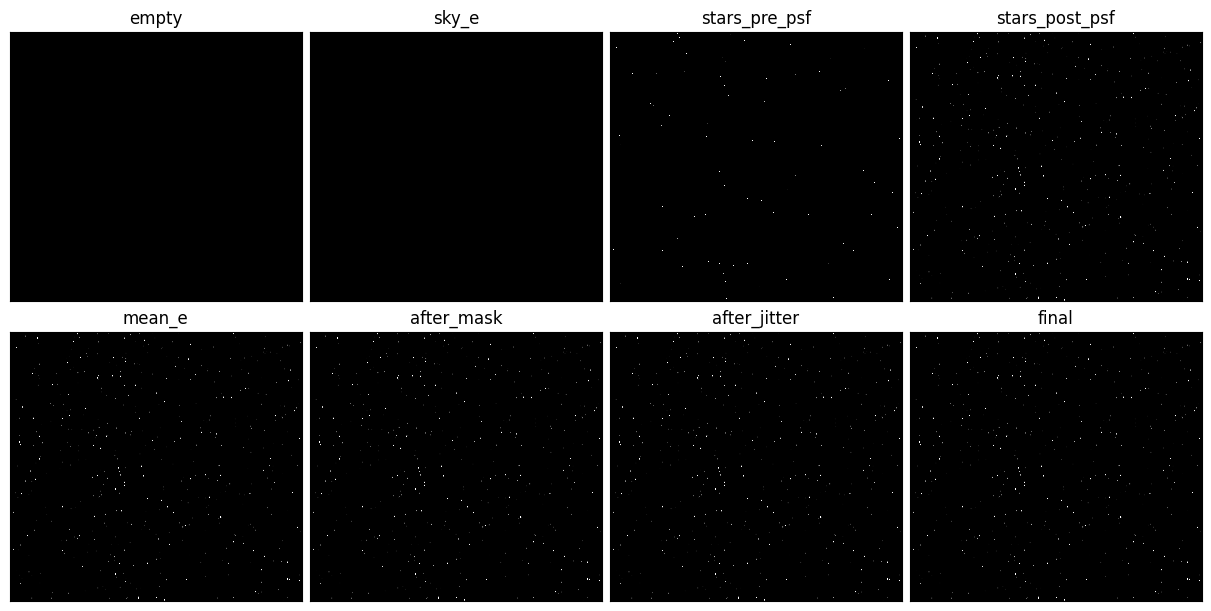

In [15]:
plot_render_stages(frameB, resB,
                   stretch="asinh",
                   cmap="gray",
                   shared_scale=True)

In [16]:
resB

RenderResult(sky_e=array([[0.03, 0.03, 0.03, ..., 0.03, 0.03, 0.03],
       [0.03, 0.03, 0.03, ..., 0.03, 0.03, 0.03],
       [0.03, 0.03, 0.03, ..., 0.03, 0.03, 0.03],
       ...,
       [0.03, 0.03, 0.03, ..., 0.03, 0.03, 0.03],
       [0.03, 0.03, 0.03, ..., 0.03, 0.03, 0.03],
       [0.03, 0.03, 0.03, ..., 0.03, 0.03, 0.03]], dtype=float32), stars_e_pre_psf=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), stars_e_post_psf=array([[ 2.88197799e-17,  3.09481851e-17,  2.38151469e-17, ...,
        -1.35247761e-17, -4.17367279e-17, -5.62589688e-17],
       [ 1.39554462e-16,  1.07455784e-16,  4.59764653e-17, ...,
         3.12447955e-17, -8.19634409e-18, -2.58932198e-17],
       [ 1.51289465e-17,  2.91217827e-18, -1.97668588e-17, ...,
        -1.27272979e-17, -6.39241075e-17, -7.45328

In [ ]:
re

Mean (should ~100): 99.97438
Variance (should ~100 + 5^2 = 125): 124.86045


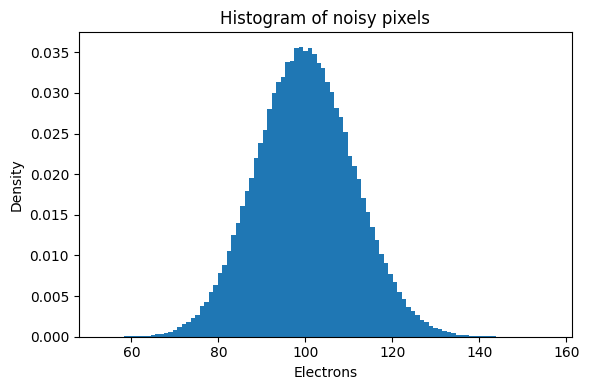

In [35]:
# Synthetic constant image
true_level = 100.0   # electrons
shape = (512, 512)

image = np.full(shape, true_level, dtype=np.float32)

class DummyCfg:
    read_noise_e = 5.0

rng = np.random.default_rng(42)

noisy = apply_noise(image, None, DummyCfg(), rng=rng)

print("Mean (should ~100):", np.mean(noisy))
print("Variance (should ~100 + 5^2 = 125):", np.var(noisy))

plt.figure(figsize=(6,4))
plt.hist(noisy.ravel(), bins=100, density=True)
plt.title("Histogram of noisy pixels")
plt.xlabel("Electrons")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [38]:
np.max(img_post)

300.059

In [42]:
print("exposure_s:", cfg_noiseless.exposure_s)
print("sky_e_per_px_s:", cfg_noiseless.sky_e_per_px_s)
print("zeropoint_e_per_s:", cfg_noiseless.zeropoint_e_per_s)
print("read_noise_e:", cfg_noisy.read_noise_e)

exposure_s: 100.0
sky_e_per_px_s: 3.0
zeropoint_e_per_s: 2.0
read_noise_e: 5.0
